# Data Analysis and Geostatistics

## Class 1: Python Basics

Welcome, again!

Feel free to zoom off if you're a Python pro!

## Python as a calculator

Python can perform standard arithmetic directly.

In [ ]:
print(7 + 3)        # addition
print(7 - 3)        # subtraction
print(7 * 3)        # multiplication
print(7 / 3)        # division      → always gives a float
print(7 // 3)       # floor division → drops the remainder
print(7 % 3)        # modulo         → the remainder
print(7 ** 3)       # exponentiation (NOT ^, which means something else in Python)

Operator precedence follows normal mathematical rules: `**` first, then `*` and `/`,
then `+` and `-`. 

In [ ]:
print(2 + 3 * 4)      # 14, not 20
print((2 + 3) * 4)    # 20

In [ ]:
# Example: area of a rectangular sampling region
length_m = 120
width_m = 75

area_m2 = length_m * width_m
area_m2

## Variables

A variable is a name attached to a value. Assign with a single `=`.

In [1]:
well_name = "Sunburst-3"
depth_m = 1204.5
porosity = 0.182
is_producing = True

print(well_name, depth_m, porosity, is_producing)

Sunburst-3 1204.5 0.182 True


**Naming rules (enforced by Python):**

- Letters, digits, and underscores only; cannot start with a digit.
- Case-sensitive: `Depth`, `depth`, and `DEPTH` are three different variables.
- Cannot be a reserved word (`for`, `if`, `class`, `lambda`, `import`, ...).

---
## Types

Every value has a type. `type()` tells you which. The four you have seen so far:

| Type | Name | Example |
|---|---|---|
| `int` | integer | `250` |
| `float` | real number | `1204.5` |
| `str` | text string | `"Sunburst-3"` |
| `bool` | boolean | `True`, `False` |

Read more [here](https://www.geeksforgeeks.org/python/python-data-types/).

In [3]:
print(type(250))
print(type(1204.5))
print(type("Sunburst-3"))
print(type(True))

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>


You can convert between types when it makes sense. Note that `int()` **truncates**
toward zero rather than rounding.

In [4]:
print(int("42") + 1)        # string → int
print(float("0.182"))       # string → float
print(str(1204.5) + " m")   # number → string, so it can be concatenated
print(int(3.99))            # → 3, truncated, NOT rounded
print(round(3.99))          # → 4, if rounding is what you meant

43
0.182
1204.5 m
3
4


Mixing types that don't mix gives a `TypeError`. Uncomment the line below and run it
to see the message. Reading error messages is a skill you will learn throughout this course.

In [ ]:
# print("Depth: " + 1204.5)      # TypeError: can only concatenate str (not "float") to str
print("Depth: " + str(1204.5))   # this is the fix

TypeError: can only concatenate str (not "float") to str

---
## Strings and f-strings

Strings are text, in single or double quotes (Python doesn't care which, but be
consistent). Triple quotes span multiple lines.

For building output, use an **f-string**: prefix the string with `f` and put any
Python expression inside `{}`.


In [7]:
site = "North Ridge"
variable = "Copper"
units = "percent"

print(site)
print(variable)

North Ridge
Copper


A convenient way to combine text and variables is an **f-string**.


In [8]:
mean_grade = 0.74

print(f"The mean {variable} value at {site} is {mean_grade} {units}.")

The mean Copper value at North Ridge is 0.74 percent.


> ## Your turn 
>
> A core plug measures 4.87 cm long and 2.54 cm in diameter. Its dry mass is 61.2 g
> and its grain density is 2.65 g/cm³.
>
> In the cell below:
> 1. Store each of those four numbers in a well-named variable (include the units in
>    the names).
> 2. Compute the bulk volume of the cylinder, $V = \pi r^2 L$. Use `3.14159` for now.
> 3. Compute the grain volume, $V_{grain} = \text{mass} / \rho_{grain}$.
> 4. Compute porosity as $\phi = (V - V_{grain}) / V$.
> 5. Print a single sentence using an f-string that reports the porosity as a
>    percentage with **one** decimal place. use `round()` for now.

In [ ]:
# Your code here:



---
## Lists

A **list** stores multiple values in order. It has a square brackets and is comma-separated.
Lists are where most of your data lives before you graduate to NumPy arrays.


In [11]:
porosities = [0.18, 0.09, 0.24, 0.15, 0.21]
well_names = ["A-01", "A-02", "B-07", "B-11", "C-03"]

print(porosities)
print(len(porosities))          # how many items
print(sum(porosities))          # total
print(sum(porosities) / len(porosities))   # the mean, computed by hand
print(min(porosities), max(porosities))

[0.18, 0.09, 0.24, 0.15, 0.21]
5
0.87
0.174
0.09 0.24


### Indexing

**Python counts from zero.** The first item is `[0]`. Negative indices count back from
the end, which is genuinely useful: `[-1]` is always the last item.

```
   porosities:   0.18   0.09   0.24   0.15   0.21
   index:          0      1      2      3      4
   from the end:  -5     -4     -3     -2     -1
```

In [12]:
print(porosities[0])      # first
print(porosities[2])      # third
print(porosities[-1])     # last
print(porosities[-2])     # second to last

0.18
0.24
0.21
0.15


### Slicing

`list[start:stop]` gives you items from `start` **up to but not including** `stop`.

In [ ]:
print(porosities[0:3])    # items 0, 1, 2
print(porosities[:3])     # same — start defaults to 0
print(porosities[2:])     # from item 2 to the end
print(porosities[-2:])    # last two
print(porosities[::2])    # every 2nd item — the third number is the step
print(porosities[::-1])   # reversed

### Modifying lists

In [16]:
samples = [0.18, 0.09, 0.24]

samples.append(0.15)          # add one item to the end
samples.extend([0.21, 0.11])  # add several
samples[0] = 0.19             # replace by index
removed = samples.pop()       # remove and return the last item

print(samples, "| removed:", removed)

print("Sorted:", sorted(samples))              # returns a NEW sorted list
print("Original:", samples)                      # original untouched
samples.sort()                      # sorts IN PLACE, returns None
print(samples)

[0.19, 0.09, 0.24, 0.15, 0.21] | removed: 0.11
Sorted: [0.09, 0.15, 0.19, 0.21, 0.24]
Original: [0.19, 0.09, 0.24, 0.15, 0.21]
[0.09, 0.15, 0.19, 0.21, 0.24]


> ## Your turn
>
> The list below holds measured depths, in metres, of a marker horizon in eight wells.
>
> ```python
> depths = [1204.5, 1211.0, 1198.3, 1220.7, 1207.2, 1215.9, 1192.4, 1209.8]
> ```
>
> In the cell below:
> 1. Print how many wells there are.
> 2. Print the shallowest and deepest values.
> 3. Print the mean depth, rounded to one decimal place.
> 4. Print the first three depths, and separately the last two.
> 5. One well was mis-recorded: the value `1192.4` should be `1292.4`. Fix it **by
>    index** and print the corrected list.
> 6. Print the corrected list sorted from deepest to shallowest.

In [ ]:
# Your code here

## Stop Here!

But feel free to continue if you have more time.

---
## Tuples and dictionaries

A **tuple** is an immutable list and uses round brackets instead of square. Use it for things
that shouldn't change, like a coordinate pair.

In [ ]:
location = (452300.0, 4821750.0)     # (easting, northing) in metres, UTM
easting, northing = location         # "unpacking" — very idiomatic Python

print(f"E {easting:.1f}, N {northing:.1f}")

# location[0] = 999.0     # → TypeError: tuples cannot be modified

A **dictionary** maps **keys** to **values**. Curly braces, `key: value` pairs. This
is the right structure whenever "look something up by name" is the operation you want.

In [ ]:
sample = {
    "id": "A-01",
    "depth_m": 1204.5,
    "porosity": 0.182,
    "permeability_mD": 45.3,
    "facies": "sandstone",
}

print(sample["porosity"])                  # look up by key
sample["density_gcc"] = 2.41               # add a new key
sample["porosity"] = 0.185                 # update an existing one

print(sample.keys())
print(sample.values())
print("facies" in sample)                  # test whether a key exists
print(sample.get("age_Ma", "not recorded"))  # safe lookup with a fallback

In [ ]:
# Looping over a dictionary gives you keys and values together
for key, value in sample.items():
    print(f"{key:>16} : {value}")

---
# NumPy arrays

For numerical analysis, Python lists are useful, but **NumPy arrays** are usually more powerful.

NumPy is one of the main numerical computing libraries used in Python.


In [19]:
import numpy as np

In [24]:
grades = np.array([0.45, 0.83, 1.12, 0.67, 1.35])

grades

array([0.45, 0.83, 1.12, 0.67, 1.35])

NumPy lets us perform calculations on entire arrays at once. You can't do this with a list.


In [21]:
grades * 100

array([ 45.,  83., 112.,  67., 135.])

In [22]:
print("Mean:", np.mean(grades))
print("Median:", np.median(grades))
print("Standard deviation:", np.std(grades))
print("Minimum:", np.min(grades))
print("Maximum:", np.max(grades))

Mean: 0.884
Median: 0.83
Standard deviation: 0.31934933849939323
Minimum: 0.45
Maximum: 1.35


### Why NumPy matters

Many data-analysis and geostatistical operations involve large collections of numerical values.

Instead of processing one number at a time, NumPy allows us to work efficiently with entire arrays.


## Your turn

Create a NumPy array containing these measurements:

`12.1, 13.5, 11.8, 15.2, 14.7, 12.9, 16.1`

Calculate:

1. the mean,
2. the median,
3. the minimum,
4. the maximum,
5. the standard deviation.

Then add one unusually large value, such as `40.0`, and calculate the mean and median again. Try `np.append(grades, number)`.

**Question:** Which statistic changed more: the mean or the median?


In [ ]:
# Your code here



---
# Comparisons and Boolean values

Python can evaluate logical conditions.


In [ ]:
grade = 1.25

print(grade > 1.0)
print(grade < 0.5)
print(grade == 1.25)

Common comparison operators:

| Meaning | Operator |
|---|---|
| Equal to | `==` |
| Not equal to | `!=` |
| Greater than | `>` |
| Less than | `<` |
| Greater than or equal to | `>=` |
| Less than or equal to | `<=` |


In [ ]:
grades = np.array([0.45, 0.83, 1.12, 0.67, 1.35])

grades > 1.0

In [ ]:
high_grade = grades[grades > 1.0]
high_grade

This idea, selecting observations that satisfy a condition, is very important in data analysis.


## Your turn

Using the array below, select only values greater than or equal to `10`.

Then calculate the mean of the selected values.

In [ ]:
measurements = np.array([4.2, 11.5, 8.7, 14.1, 9.9, 12.6, 5.4])

# Your turn

---
# Part 8 — Functions

A **function** packages a reusable calculation.

Python already provides many functions such as `print()`, `len()`, and `type()`.

We can also create our own functions using `def`.


In [ ]:
def celsius_to_fahrenheit(celsius):
    fahrenheit = celsius * 9 / 5 + 32
    return fahrenheit

celsius_to_fahrenheit(20)

Here is a slightly more course-related example.


In [ ]:
def coefficient_of_variation(values):
    values = np.asarray(values)
    return np.std(values) / np.mean(values)

coefficient_of_variation(grades)

## Your turn

Write a function called `meters_to_kilometers` that converts meters to kilometers.

Test your function using:

`3500 meters`

The result should be `3.5 kilometers`.


In [ ]:
# Your code here:



---
# Pandas and tabular data

Most real datasets are organized as rows and columns.

The **pandas** library provides a structure called a **DataFrame** for working with tabular data.


In [28]:
import pandas as pd

In [29]:
data = pd.DataFrame({
    "sample_id": ["S1", "S2", "S3", "S4", "S5"],
    "x": [100, 125, 150, 175, 200],
    "y": [250, 260, 240, 270, 255],
    "grade": [0.45, 0.83, 1.12, 0.67, 1.35]
})

data

,sample_id,x,y,grade
0,S1,100,250,0.45
1,S2,125,260,0.83
2,S3,150,240,1.12
3,S4,175,270,0.67
4,S5,200,255,1.35


Useful first commands when examining a DataFrame:


In [ ]:
data.head()

In [ ]:
data.shape

In [ ]:
data.columns

In [ ]:
data.describe()

We can select one column:


In [ ]:
data["grade"]

Or filter rows:


In [ ]:
data[data["grade"] > 1.0]

## Your turn

Using the `data` DataFrame:

1. Display the `x` column.
2. Calculate the mean grade.
3. Find the row with the largest grade.
4. Select all samples with grade greater than `0.75`.
5. How many samples satisfy that condition?


In [ ]:
# Your code here:



---
# Plotting data

Visualization is one of the most important parts of data analysis.

We will use **Matplotlib** throughout the course.


In [30]:
import matplotlib.pyplot as plt

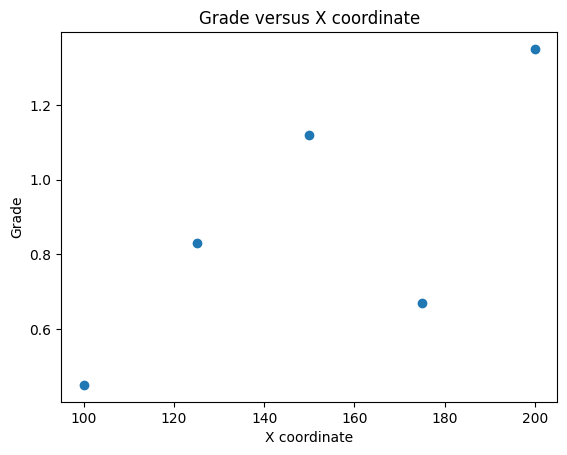

In [31]:
plt.scatter(data["x"], data["grade"])
plt.xlabel("X coordinate")
plt.ylabel("Grade")
plt.title("Grade versus X coordinate")
plt.show()

Plots should normally include:

- meaningful axis labels,
- units when appropriate,
- a descriptive title when useful.

Later in the course, we will create maps, histograms, spatial plots, variograms, and prediction maps.


## Your turn

Create a scatter plot of:

- `x` coordinate on the horizontal axis
- `y` coordinate on the vertical axis

Add:

1. an x-axis label,
2. a y-axis label,
3. a title.

Then change the plot so that point size depends on `grade`.

Hint: `plt.scatter()` has an argument called `s`.


In [ ]:
# Your code here



---
# A small data-analysis workflow

A typical analysis often follows a sequence like this:

1. Load or create data.
2. Inspect the data.
3. Clean or filter the data.
4. Calculate useful statistics.
5. Visualize the data.
6. Interpret the result.

Let's combine several ideas from today's class.


In [32]:
samples = pd.DataFrame({
    "x": [10, 20, 30, 40, 50, 60, 70, 80],
    "y": [15, 18, 25, 22, 35, 31, 42, 45],
    "value": [5.2, 5.8, 6.1, 5.6, 7.4, 8.0, 7.7, 9.1]
})

samples

,x,y,value
0,10,15,5.2
1,20,18,5.8
2,30,25,6.1
3,40,22,5.6
4,50,35,7.4
5,60,31,8.0
6,70,42,7.7
7,80,45,9.1


In [33]:
samples.describe()

,x,y,value
count,8.000000,8.000000,8.000000
mean,45.000000,29.125000,6.862500
std,24.494897,10.999188,1.381446
min,10.000000,15.000000,5.200000
25%,27.500000,21.000000,5.750000
50%,45.000000,28.000000,6.750000
75%,62.500000,36.750000,7.775000
max,80.000000,45.000000,9.100000


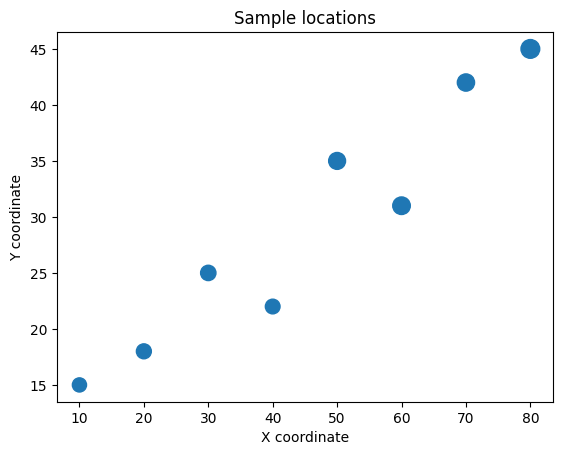

In [34]:
plt.scatter(samples["x"], samples["y"], s=samples["value"] * 20)
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Sample locations")
plt.show()

## Your turn

Using the `samples` dataset above:

1. Calculate the mean of `value`.
2. Calculate the standard deviation of `value`.
3. Find all samples where `value` is greater than the mean.
4. Count how many samples satisfy this condition.
5. Make a plot of `x` versus `value`.
6. In a Markdown cell, write **2–3 sentences** describing what you observe.

There is no need for a complicated interpretation yet. Focus on making a clear, reproducible analysis.


In [ ]:
# Your code here:



---
# Common errors are normal

Programming errors are part of computational work.

Here are three common categories:

### Syntax errors
Python cannot understand the structure of the code.

### Name errors
You try to use a variable that has not been defined.

### Type errors
An operation is attempted on incompatible types.

When an error occurs:

1. Read the final line of the error message.
2. Identify the cell and line that caused the problem.
3. Check variable names, punctuation, and data types.
4. Change one thing at a time.
5. Run the cell again.

Errors are information. Learning to read them is an important computational skill.


## Your turn

The following code contains errors.

Fix the code so that it calculates and prints the mean sample value.


In [ ]:
# Intentionally broken code

sample_values = [4.2, 5.1, 6.3, 5.7, 7.0]

# mean_value = sum(sample_value) / len(sample_values)
# print("Mean sample value = " + mean_value)

# Remove the # symbols above and fix the errors.


NameError: name 'sample_value' is not defined

---
# Put it together

Create your own small dataset with at least **8 observations** and the following columns:

- `x`
- `y`
- `value`

You may invent the data.

Then:

1. Store the data in a pandas DataFrame.
2. Display the DataFrame.
3. Calculate summary statistics.
4. Calculate the mean of `value`.
5. Identify observations above the mean.
6. Create a scatter plot of the sample locations.
7. Create a second plot showing `x` versus `value`.
8. Write a short Markdown interpretation of what you see.

### Your turn
Try to complete this without copying the previous example line by line.


In [ ]:
# Your code here



---
# What we learned today

Today you worked with:

- Jupyter Notebook cells
- Markdown and code
- Python variables
- numbers, strings, and Boolean values
- lists
- NumPy arrays
- comparisons and filtering
- functions
- pandas DataFrames
- basic statistics
- Matplotlib plots
- debugging
- reproducible analysis

You do **not** need to memorize every command.

The more important goal is to become comfortable with the workflow:

> **Question → Data → Code → Result → Visualization → Interpretation**

In upcoming classes, we will build on these ideas and move toward more sophisticated data analysis and eventually **spatial data analysis and geostatistics**.
